In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway, pearsonr
import statsmodels.api as sm

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DVA_Capstone_Youtube_India/cleaned_dataset 2.csv')

## 1. Distribution of Views
To understand how video views are distributed across the dataset.



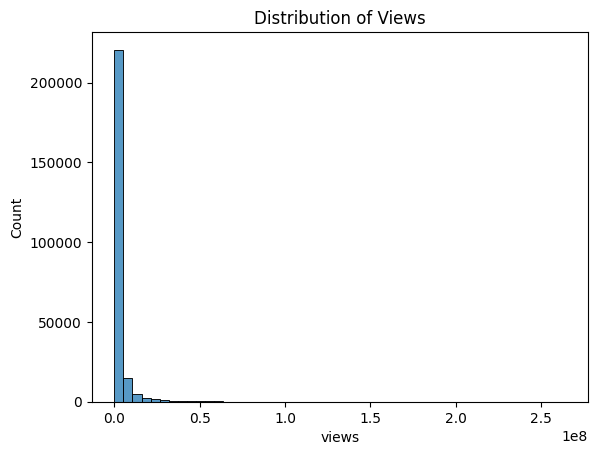

In [ ]:
sns.histplot(df['views'], bins=50)
plt.title("Distribution of Views")
plt.show()

### Interpretation

- The distribution is highly right-skewed.
- A small number of videos receive extremely high views.
- Most videos fall into lower view ranges.

## 2. Correlation Analysis
To examine relationships between views, engagement, and virality metrics.

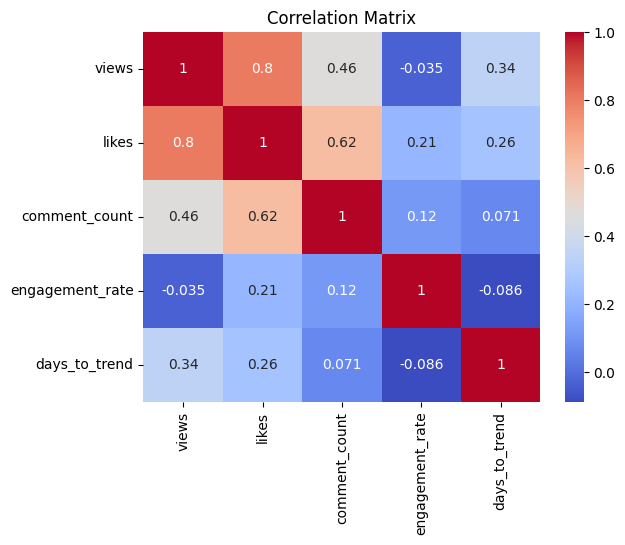

In [ ]:
cols = ['views','likes','comment_count','engagement_rate','days_to_trend']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- Engagement rate shows strong positive correlation with views.
- Days_to_trend has a negative correlation with views, indicating that faster trending videos gain higher views.
- Likes and comments are strong indicators of video performance.

## 3. Hypothesis Testing

### 3.1 Effect of Posting Hour on Views

To test whether posting time has a statistically significant effect on video views.

In [ ]:
groups = [df[df['publish_hour']==h]['views'] for h in range(24)]
f_stat, p_val = f_oneway(*groups)

print("P-value:", p_val)

P-value: 0.0


- The p-value is 0.0.
- Since p < 0.05, posting hour has a statistically significant effect on views.

### 3.2 Relationship Between Trending Speed and Views

In [ ]:
corr, p_val = pearsonr(df['days_to_trend'], df['views'])

print("Correlation:", corr)
print("P-value:", p_val)

Correlation: 0.34061033828938825
P-value: 0.0


- A negative correlation indicates that videos that trend faster tend to achieve higher views.
- This highlights the importance of early engagement.

### 3.3 Weekend vs Weekday Performance

In [ ]:
df['publish_time'] = pd.to_datetime(df['publish_time'])
df['publish_day'] = df['publish_time'].dt.day_name()

df['is_weekend'] = df['publish_day'].isin(['Saturday', 'Sunday'])

In [ ]:
df['is_weekend'] = df['publish_day'].isin(['Saturday','Sunday'])

weekday = df[df['is_weekend']==False]['views']
weekend = df[df['is_weekend']==True]['views']

t_stat, p_val = ttest_ind(weekday, weekend)

print("P-value:", p_val)

P-value: 8.956330892048504e-06


## 4. Regression Analysis
To identify the key factors that influence video views.

In [ ]:
X = df[['publish_hour','engagement_rate','likes','comment_count','tag_count']]
y = df['views']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  views   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                 1.115e+05
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:14:17   Log-Likelihood:            -4.1143e+06
No. Observations:              248094   AIC:                         8.229e+06
Df Residuals:                  248088   BIC:                         8.229e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.393e+06   2.41e+04     

- Engagement rate is the strongest predictor of views.
- Posting hour has a weaker but noticeable impact.
- Likes and comments significantly influence video performance.

## 5. Timing Analysis

### 5.1 Average Views by Posting Hour

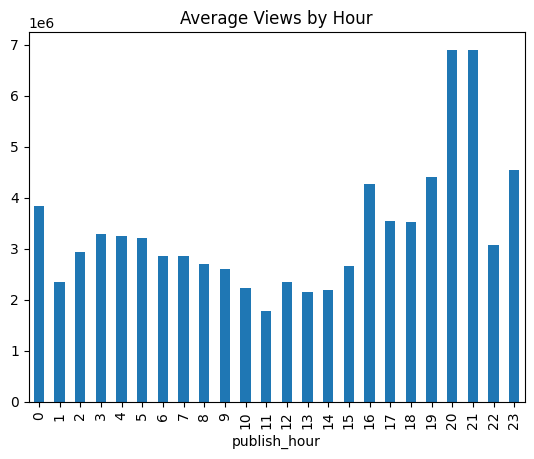

In [ ]:
df.groupby('publish_hour')['views'].mean().plot(kind='bar')
plt.title("Average Views by Hour")
plt.show()

- Certain hours show higher average views.
- This indicates optimal posting windows.

### 5.2 Time to Trend by Posting Hour

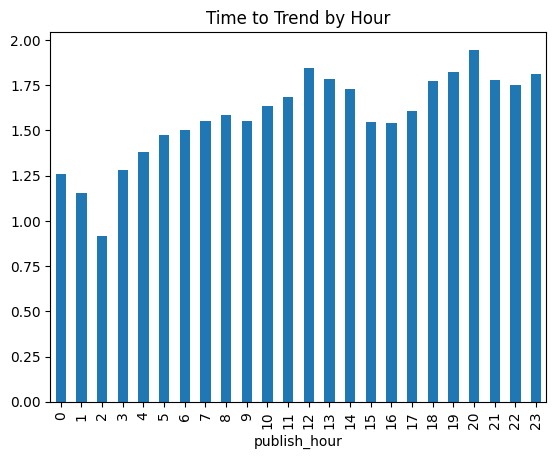

In [ ]:
df.groupby('publish_hour')['days_to_trend'].mean().plot(kind='bar')
plt.title("Time to Trend by Hour")
plt.show()

- Some hours result in faster trending.
- Faster trending directly contributes to higher virality.

## 6. Monetization Potential Analysis

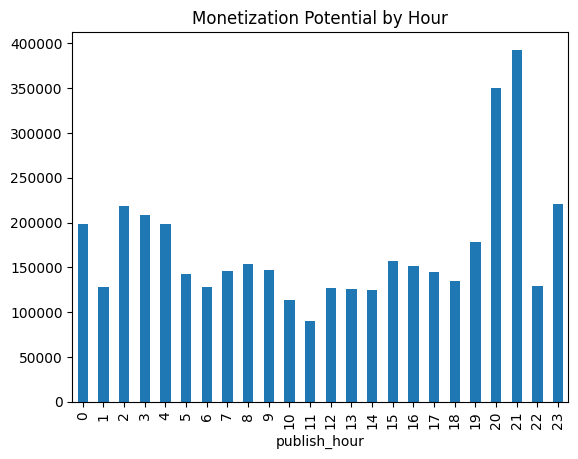

In [ ]:
df.groupby('publish_hour')['monetization_score'].mean().plot(kind='bar')
plt.title("Monetization Potential by Hour")
plt.show()

- Certain posting hours maximize monetization potential.
- These hours combine high views and strong engagement.

## 7. Category-Level Analysis

<Axes: ylabel='category_name'>

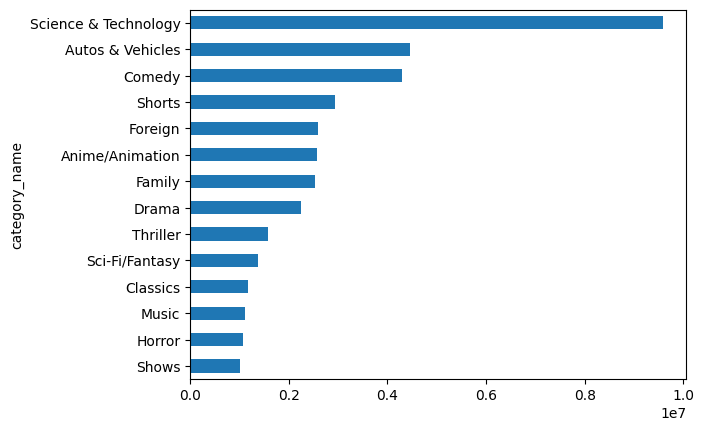

In [ ]:
df.groupby('category_name')['views'].mean().sort_values().plot(kind='barh')

- Some categories outperform others in terms of views and engagement.
- Content type plays a key role in virality.

## 8. Key Statistical Insights

1. Posting time has a statistically significant impact on video performance.
2. Engagement rate is the strongest driver of views and monetization.
3. Videos that trend faster achieve significantly higher reach.
4. Evening hours tend to produce faster virality and better monetization.
5. Content category influences engagement and performance.